# Phase 1: Data Overview and Metadata Inspection

This notebook inspects the Kaggle-extracted HAM10000 dataset already present in `data/`, validates the metadata file, summarizes the class imbalance, and saves report-friendly artifacts.

The focus here is on understanding the raw data before any splitting or preprocessing work.

In [7]:
from pathlib import Path

import json

import pandas as pd

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
data_root = project_root / "data"
raw_dir = data_root / "raw"
artifact_dir = project_root / "reports" / "artifacts"
figure_dir = project_root / "reports" / "figures"

artifact_dir.mkdir(parents=True, exist_ok=True)
figure_dir.mkdir(parents=True, exist_ok=True)

metadata_path = raw_dir / "HAM10000_metadata.csv"
all_image_dirs = sorted(path for path in raw_dir.iterdir() if path.is_dir() and "images_part" in path.name.lower())
canonical_image_dirs = [path for path in all_image_dirs if path.name.startswith("HAM10000_")]
if not canonical_image_dirs:
    canonical_image_dirs = all_image_dirs

print(json.dumps({
    "project_root": str(project_root),
    "data_root": str(data_root),
    "raw_dir": str(raw_dir),
    "metadata_exists": metadata_path.exists(),
    "all_image_directories": [str(path) for path in all_image_dirs],
    "canonical_image_directories": [str(path) for path in canonical_image_dirs],
}, indent=2))

{
  "project_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code",
  "data_root": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data",
  "raw_dir": "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw",
  "metadata_exists": true,
  "all_image_directories": [
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_1",
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_2"
  ],
  "canonical_image_directories": [
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_1",
    "/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_2"
  ]
}


In [8]:
if not metadata_path.exists():
    raise FileNotFoundError(f"Metadata file not found: {metadata_path}")

metadata_df = pd.read_csv(metadata_path)
metadata_summary = {
    "rows": int(len(metadata_df)),
    "columns": list(metadata_df.columns),
    "unique_lesions": int(metadata_df['lesion_id'].nunique()),
    "class_counts": metadata_df['dx'].value_counts().to_dict(),
    "missing_values": metadata_df.isna().sum().to_dict(),
}

print(json.dumps(metadata_summary, indent=2))
metadata_df.head(10)

{
  "rows": 10015,
  "columns": [
    "lesion_id",
    "image_id",
    "dx",
    "dx_type",
    "age",
    "sex",
    "localization"
  ],
  "unique_lesions": 7470,
  "class_counts": {
    "nv": 6705,
    "mel": 1113,
    "bkl": 1099,
    "bcc": 514,
    "akiec": 327,
    "vasc": 142,
    "df": 115
  },
  "missing_values": {
    "lesion_id": 0,
    "image_id": 0,
    "dx": 0,
    "dx_type": 0,
    "age": 57,
    "sex": 0,
    "localization": 0
  }
}


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear
5,HAM_0001466,ISIC_0027850,bkl,histo,75.0,male,ear
6,HAM_0002761,ISIC_0029176,bkl,histo,60.0,male,face
7,HAM_0002761,ISIC_0029068,bkl,histo,60.0,male,face
8,HAM_0005132,ISIC_0025837,bkl,histo,70.0,female,back
9,HAM_0005132,ISIC_0025209,bkl,histo,70.0,female,back


Saved class distribution plot to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/figures/ham10000_class_distribution.png


,diagnosis,count,percentage
0,nv,6705,66.95
1,mel,1113,11.11
2,bkl,1099,10.97
3,bcc,514,5.13
4,akiec,327,3.27
5,vasc,142,1.42
6,df,115,1.15


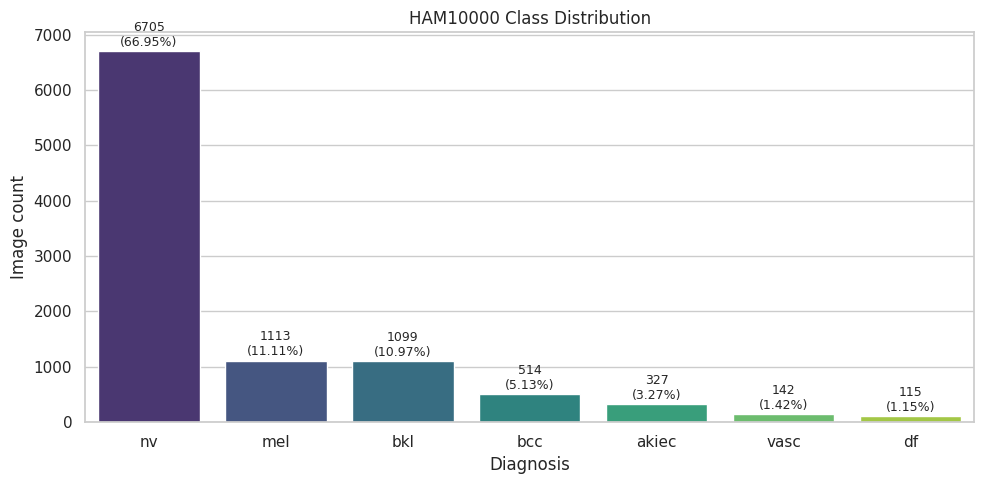

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

class_counts = metadata_df['dx'].value_counts().sort_values(ascending=False)
class_counts_df = class_counts.rename_axis('diagnosis').reset_index(name='count')
class_counts_df['percentage'] = (class_counts_df['count'] / len(metadata_df) * 100).round(2)

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette('viridis', n_colors=len(class_counts_df))
sns.barplot(data=class_counts_df, x='diagnosis', y='count', hue='diagnosis', dodge=False, palette=palette, legend=False, ax=ax)
ax.set_title('HAM10000 Class Distribution')
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Image count')
for index, row in class_counts_df.iterrows():
    ax.text(index, row['count'] + 40, f"{row['count']}\n({row['percentage']}%)", ha='center', va='bottom', fontsize=9)
fig.tight_layout()
class_plot_path = figure_dir / 'ham10000_class_distribution.png'
fig.savefig(class_plot_path, dpi=160, bbox_inches='tight')
print(f'Saved class distribution plot to {class_plot_path}')
class_counts_df

In [10]:
candidate_image_dirs = [path for path in canonical_image_dirs if path.exists()]

image_dir_summary = []

for path in candidate_image_dirs:

    image_count = sum(1 for _ in path.glob('*.jpg'))

    image_dir_summary.append({

        'directory': str(path),

        'jpg_count': image_count,

    })



ignored_image_dirs = [path for path in all_image_dirs if path not in canonical_image_dirs]

if ignored_image_dirs:

    print('Ignored duplicate image directories:')

    for path in ignored_image_dirs:

        print(f'  - {path}')



image_summary_df = pd.DataFrame(image_dir_summary)

print(image_summary_df.to_string(index=False))



summary_path = artifact_dir / 'ham10000_metadata_summary.json'

summary_path.write_text(json.dumps(metadata_summary, indent=2), encoding='utf-8')

image_summary_path = artifact_dir / 'ham10000_image_directories.csv'

image_summary_df.to_csv(image_summary_path, index=False)

print(f'Saved metadata summary to {summary_path}')

print(f'Saved image directory summary to {image_summary_path}')


                                                                directory  jpg_count
/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_1       5000
/home/selba/Desktop/ENSIAS/Mlops/PFA/code/data/raw/HAM10000_images_part_2       5015
Saved metadata summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/ham10000_metadata_summary.json
Saved image directory summary to /home/selba/Desktop/ENSIAS/Mlops/PFA/code/reports/artifacts/ham10000_image_directories.csv
